# **CAPSTONE 2**
# **EmporiUm TERRITORY ANALYSIS**

**Analyst:** Jessica Navarro

**Territory Manager:** Jim Heck

**Territory Director:** Cassie Chambers

**Territories Analyzed:**
- (West) COLORADO
- (South) TEXAS


Objective: I've analyzed the bookstore's EmporiUm sales data in two specific regions, West and South, using both Python and Jupyter Notebook. I studied the store performance, monthly sales, product categories, transactions, and top customers to gain marketing insights from the data set.

In [389]:
# Libraries:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Formatting numbers as currency and decimals as needed
pd.options.display.float_format = '${:,.2f}'.format

In [390]:
# Load the files
stores = pd.read_csv("StoreDetail.csv")
sales = pd.read_csv("StoreSales.csv")
customers = pd.read_csv("customer_list.csv", sep="|")
products = pd.read_csv("Products.csv")
categories = pd.read_csv("ProductCategories.csv")

# Clean column names
stores.columns = stores.columns.str.strip()
sales.columns = sales.columns.str.strip()
customers.columns = customers.columns.str.strip()
products.columns = products.columns.str.strip()
categories.columns = categories.columns.str.strip()

## Importing the Data

I loaded the five CSV files needed for this project into pandas DataFrames.

I cleaned the column names using `.str.strip()` so this helps remove extra spaces and make the data easier to work with throughout the analysis.

In [391]:
# Change dates into real date format
sales["Transaction Date"] = pd.to_datetime(sales["Transaction Date"])

# Create a month column for monthly charts
sales["Month"] = sales["Transaction Date"].dt.to_period("M").astype(str)

In [392]:
# Merge sales with store details
sales_stores = sales.merge(stores, on="Store ID", how="left")

# Filtering for Jim Heck's and Jeff Richards's territories
my_territories = sales_stores[
    ((sales_stores["Territory Manager"] == "Jim Heck") &
    (sales_stores["State"] == "Colorado") & (sales_stores["Region"] == "West"))
    |
    ((sales_stores["Territory Manager"] == 'Jeff "Howdy" Richards') &
    (sales_stores["State"] == "Texas") & (sales_stores["Region"] == "South"))]

# Show a clean table with no index
display(my_territories.head(10).style.hide(axis="index"))


# Jeff managed stores diplayed ONLY:
jeff_rows = my_territories[
    my_territories["Territory Manager"] == 'Jeff "Howdy" Richards'
]

display(jeff_rows.head(10).style.hide(axis="index"))

Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
2022-01-01 00:00:00,702,nan,105349-M,8.000000,2022-01,Berthoud,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,704,nan,105350-T,144.000000,2022-01,Castle Rock,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105351-M,44.000000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105352-M,47.610000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,705,nan,105353-A,20.360000,2022-01,Denver,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,706,nan,105344-IT,265.070000,2022-01,Englewood,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,707,nan,105354-T,133.100000,2022-01,Fort Collins,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,707,nan,105355-B,24.280000,2022-01,Fort Collins,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,708,nan,105356-S,13.130000,2022-01,Grand Junction,Colorado,Jim Heck,West,Cassie Chambers
2022-01-01 00:00:00,709,nan,105357-T,195.300000,2022-01,Greeley,Colorado,Jim Heck,West,Cassie Chambers


Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount,Month,Store Location,State,Territory Manager,Region,Region Director
2022-01-01 00:00:00,902,nan,105454-M,14.000000,2022-01,Austin,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,904,nan,105326-IT,1717.700000,2022-01,Baytown,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105347-IT,837.520000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105348-IT,29.810000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,906,nan,105432-S,6.020000,2022-01,Cedar Park,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,907,nan,105413-A,57.700000,2022-01,Dallas,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,908,328.000000,105337-IT,1301.880000,2022-01,Denton,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,908,nan,105445-T,178.600000,2022-01,Denton,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,909,nan,105455-S,10.100000,2022-01,Desoto,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
2022-01-01 00:00:00,910,nan,105456-T,60.720000,2022-01,Fort Worth,Texas,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


## Filtering My Assigned Territories

I merged the **sales data** with the **store details** data using `pd.merge()`. This allowed me to connect each columns such as: 
sales transaction to store, state, region, and territory manager information.

Also, I filtered the data to only include my assigned territories: Jim Heck in Colorado (West Region) and Jeff "Howdy" Richards in Texas (South Region).

And then I displayed a sample of the filtered data and created a separate view for Jeff Richards's territory to make sure that the filtering worked correctly.

# **CORE MARKETING ANALYSIS**

# **Question 1: Territory Managers and Stores**

Objective:
*I want to identify for each territory*:
- *territory managers*
- *store IDs*
- *store locations*


Territories:
- **Assigned:** *Jim Heck (Colorado - West)*
-  **Comparison:** *Jeff Richards (Texas - South)*

In [393]:
# # Jim Heck stores only
jim_stores = territory_stores[
    territory_stores["Territory Manager"] == "Jim Heck"]

display(
    jim_stores
    .sort_values("Store ID")
    .style.hide(axis="index"))

# Jeff Richards stores only
jeff_stores = territory_stores[
    territory_stores["Territory Manager"] == 'Jeff "Howdy" Richards']

display(
    jeff_stores
    .sort_values("Store ID")
    .style.hide(axis="index"))

Store Location,State,Store ID,Territory Manager,Region,Region Director
Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
Denver,Colorado,705,Jim Heck,West,Cassie Chambers
Englewood,Colorado,706,Jim Heck,West,Cassie Chambers
Fort Collins,Colorado,707,Jim Heck,West,Cassie Chambers
Grand Junction,Colorado,708,Jim Heck,West,Cassie Chambers
Greeley,Colorado,709,Jim Heck,West,Cassie Chambers
Lafayette,Colorado,710,Jim Heck,West,Cassie Chambers


Store Location,State,Store ID,Territory Manager,Region,Region Director
Arlington,Texas,901,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Austin,Texas,902,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Bacliff,Texas,903,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Baytown,Texas,904,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Beaumont,Texas,905,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Cedar Park,Texas,906,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Dallas,Texas,907,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Denton,Texas,908,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Desoto,Texas,909,"Jeff ""Howdy"" Richards",South,Andy Gisselquist
Fort Worth,Texas,910,"Jeff ""Howdy"" Richards",South,Andy Gisselquist


I separated the stores by territory manager to clearly identify which stores belong to Jim Heck's territory and which stores belong to Jeff "Howdy" Richards's territory.

# **Question 2: Monthly Revenue**

Objective:

*I want to compare monthly sales revenue between the two territories. This will help identify sales trends over time.*

In [394]:
# Monthly revenue

monthly_revenue = my_territories.groupby(
    ["Month", "Territory Manager"],
    as_index=False
)["Sale Amount"].sum()

monthly_revenue = monthly_revenue.rename(
    columns={"Sale Amount": "Monthly Revenue"}
)

# Convert Month column to Month Year format
monthly_revenue["Month"] = pd.to_datetime(monthly_revenue["Month"])

monthly_revenue["Month_Label"] = monthly_revenue["Month"].dt.strftime("%b %Y")

# Clean table output
display(
    monthly_revenue.style
    .format({
        "Monthly Revenue": "${:,.2f}"
    })
    .hide(axis="index")
)

Month,Territory Manager,Monthly Revenue,Month_Label
2022-01-01 00:00:00,"Jeff ""Howdy"" Richards","$40,857.20",Jan 2022
2022-01-01 00:00:00,Jim Heck,"$77,950.98",Jan 2022
2022-02-01 00:00:00,"Jeff ""Howdy"" Richards","$52,729.22",Feb 2022
2022-02-01 00:00:00,Jim Heck,"$80,315.69",Feb 2022
2022-03-01 00:00:00,"Jeff ""Howdy"" Richards","$49,214.95",Mar 2022
2022-03-01 00:00:00,Jim Heck,"$82,516.36",Mar 2022
2022-04-01 00:00:00,"Jeff ""Howdy"" Richards","$55,229.25",Apr 2022
2022-04-01 00:00:00,Jim Heck,"$89,350.31",Apr 2022
2022-05-01 00:00:00,"Jeff ""Howdy"" Richards","$49,696.98",May 2022
2022-05-01 00:00:00,Jim Heck,"$94,892.89",May 2022


I used `.groupby()` and `.sum()` to calculate the total monthly revenue for each territory manager. I also used `.rename()` to create a clearer column name and converted the month column into a Month Year format to make the results easier to read.

Challege: I encountered was that the month column initially displayed a full date and time stamp. I solved this by using `.strftime("%b %Y")` to display a cleaner format such as "Jan 2024" for reporting and visualization purposes.

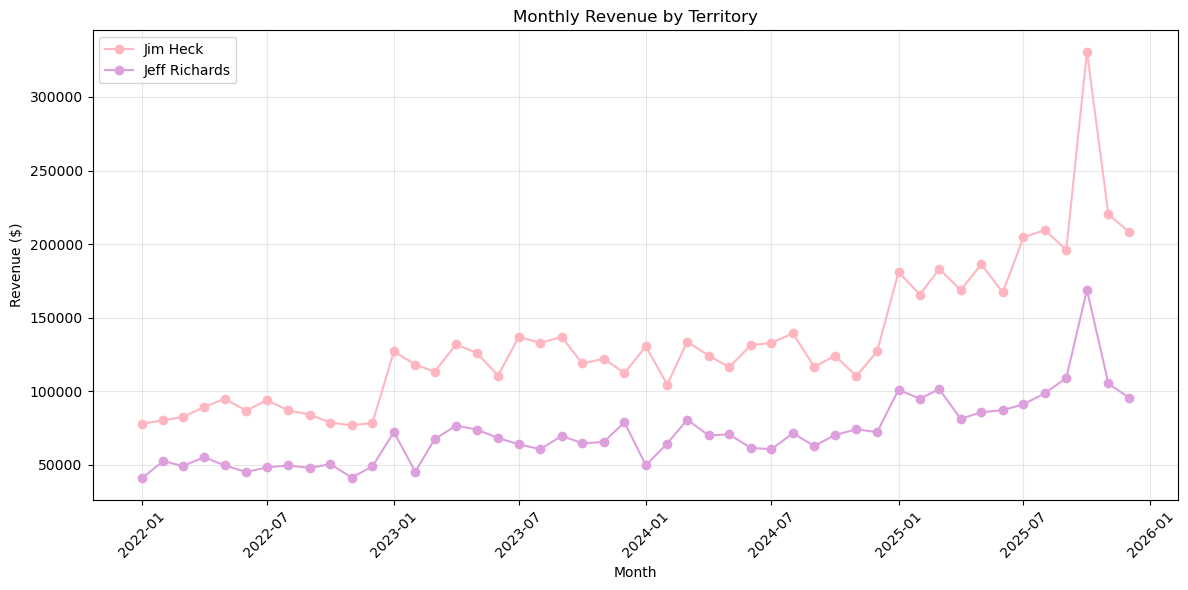

In [395]:
# Monthly revenue line chart

chart_data = monthly_revenue.pivot(
    index="Month",
    columns="Territory Manager",
    values="Monthly Revenue"
)

plt.figure(figsize=(12,6))

plt.plot(
    chart_data.index,
    chart_data["Jim Heck"],
    marker="o",
    color="lightpink",
    label="Jim Heck"
)

plt.plot(
    chart_data.index,
    chart_data['Jeff "Howdy" Richards'],
    marker="o",
    color="plum",
    label="Jeff Richards"
)

plt.title("Monthly Revenue by Territory")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

This line chart makes it easy to compare monthly revenue trends between the two territories.

# **Question 3: Store Performance**

Objective:
*I want to rank stores based on total sales revenue. This helps identify the strongest-performing stores in each territory.*

In [396]:
# Rank stores by total revenue

store_rankings = my_territories.groupby(
    ["Territory Manager", "Store ID", "Store Location"],
    as_index=False
)["Sale Amount"].sum()

store_rankings = store_rankings.rename(
    columns={"Sale Amount": "Total Revenue"}
)

# Create store rank as a whole number
store_rankings["Store Rank"] = store_rankings.groupby(
    "Territory Manager"
)["Total Revenue"].rank(
    ascending=False,
    method="dense"
).astype(int)

# Sort by manager and rank
store_rankings = store_rankings.sort_values(
    ["Territory Manager", "Store Rank"]
)

# Show clean table
display(
    store_rankings.style
    .format({
        "Total Revenue": "${:,.2f}",
        "Store Rank": "{:.0f}"
    })
    .hide(axis="index")
)

Territory Manager,Store ID,Store Location,Total Revenue,Store Rank
"Jeff ""Howdy"" Richards",905,Beaumont,"$637,818.90",1
"Jeff ""Howdy"" Richards",910,Fort Worth,"$351,772.59",2
"Jeff ""Howdy"" Richards",909,Desoto,"$330,720.12",3
"Jeff ""Howdy"" Richards",906,Cedar Park,"$312,628.27",4
"Jeff ""Howdy"" Richards",904,Baytown,"$298,163.16",5
"Jeff ""Howdy"" Richards",908,Denton,"$298,111.45",6
"Jeff ""Howdy"" Richards",901,Arlington,"$292,987.49",7
"Jeff ""Howdy"" Richards",902,Austin,"$291,145.00",8
"Jeff ""Howdy"" Richards",903,Bacliff,"$280,714.34",9
"Jeff ""Howdy"" Richards",911,Georgetown,"$269,344.64",10


So for this I used `.groupby()` and `.sum()` to calculate the total revenue for each store within each territory. Then, I used `.rank()` to rank stores from highest to lowest revenue so I could identify the top-performing locations.

Challenge: I encountered was that the store ranks were displaying as decimal values such as 1.0 and 2.0. I fixed this by using `.astype(int)` to convert the rankings into whole numbers, making the results easier to read and present.

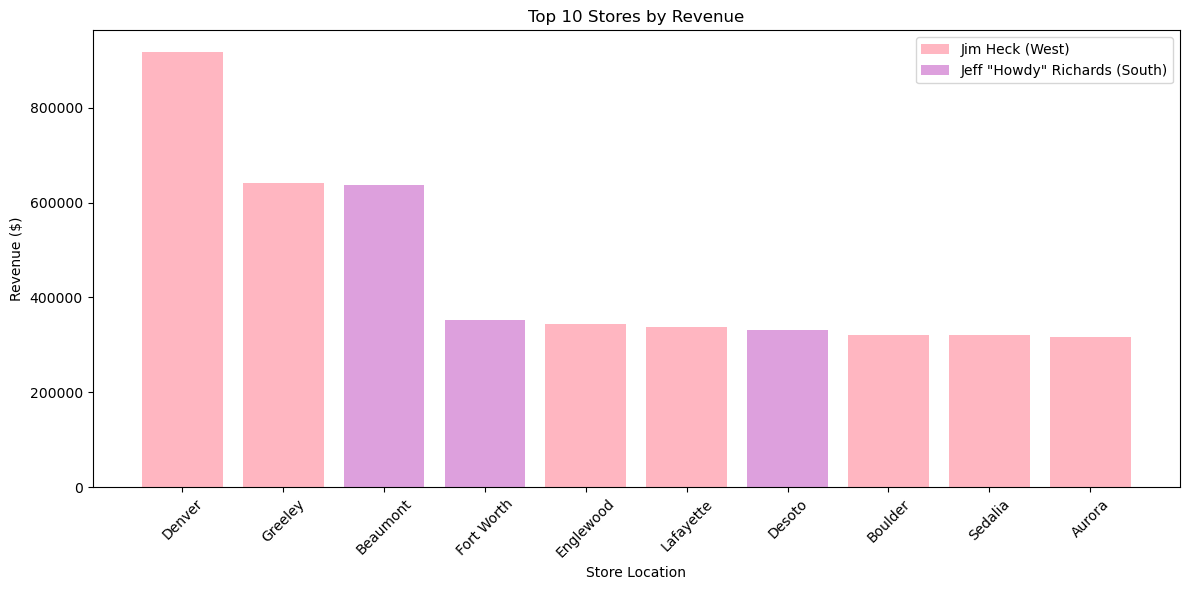

In [397]:
from matplotlib.patches import Patch

# Top stores chart
top_stores = store_rankings.sort_values(
    "Total Revenue",
    ascending=False
).head(10)

# Assign colors by territory
colors = [
    "lightpink" if manager == "Jim Heck"
    else "plum"
    for manager in top_stores["Territory Manager"]
]

plt.figure(figsize=(12,6))

plt.bar(
    top_stores["Store Location"],
    top_stores["Total Revenue"],
    color=colors
)

# Create legend
legend_items = [
    Patch(facecolor="lightpink", label="Jim Heck (West)"),
    Patch(facecolor="plum", label='Jeff "Howdy" Richards (South)')
]

plt.legend(handles=legend_items)

plt.title("Top 10 Stores by Revenue")
plt.xlabel("Store Location")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Question 4: Top Customers**

Objective: *I want to identify the rewards customers who spent the most money. This can help marketing target valuable customers.*

In [405]:
#Top Customers

# Merge customer information
sales_customers = my_territories.merge(
    customers,
    left_on="RewardsID",
    right_on="cust_id",
    how="left"
)

# Find top rewards customers by total spending
top_customers = sales_customers.groupby(
    ["cust_id", "name", "email"],
    as_index=False
)["Sale Amount"].sum()

# Rename columns
top_customers = top_customers.rename(
    columns={
        "cust_id": "Customer ID",
        "Sale Amount": "Total Spend"
    }
)

# Convert Customer ID to whole numbers
top_customers["Customer ID"] = top_customers["Customer ID"].astype("Int64")

# Sort highest spenders first
top_customers = top_customers.sort_values(
    "Total Spend",
    ascending=False
)

# Display clean formatted table
display(
    top_customers.head(10)
    .style
    .format({
        "Customer ID": "{:.0f}",
        "Total Spend": "${:,.2f}"
    })
    .hide(axis="index"))

Customer ID,name,email,Total Spend
245,Gloria Mendoza,gloria@litchfield.pen,"$7,922.46"
344,Nate Jacobs,nate@easthighland.high,"$6,975.81"
102,Jodie L.,jodie@lawndale.high,"$5,757.77"
128,Sonny Corinthos,sonny@generalhospital.med,"$5,694.26"
375,C.J. Cregg,cj@westwing.gov,"$5,673.45"
501,Betty Ramsey,betty@ricardoproductions.tv,"$5,420.84"
371,Principal Weems,weems@nevermore.academy,"$5,293.45"
409,Gerri Kellman,gerri@waystarroyco.com,"$5,139.99"
171,Clark County,clark@paperboi.atl,"$4,923.84"
242,Lorna Morello,lorna@litchfield.pen,"$4,919.83"


I used `pd.merge()` to connect the sales data with the customer data using the rewards customer ID. Then, I used `.groupby()` and `.sum()` to calculate each customer's total spending and identify the highest-spending rewards members.

Challenge: I encountered was that the customer ID values displayed as decimals. I fixed this by converting the IDs to whole numbers and formatting the spending amounts as currency. This analysis supports the marketing objective by identifying loyal, high-value customers who may be good candidates for targeted promotions and retention efforts.

# **Question 5: Product Categories**
Objective:
*I want to find out which product categories made the most money in each territory. This helps compare what customers are buying in Jim Heck's territory and Jeff Richards's territory.*

In [406]:
sales_products.columns

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount',
       'Month', 'Store Location', 'State', 'Territory Manager', 'Region',
       'Region Director', 'Product', 'CategoryID', 'SubcategoryID_x',
       'Category', 'SubcategoryID_y', 'Subcategory'],
      dtype='object')

In [400]:
# Merge product information with my territory sales

sales_products = my_territories.merge(
    products,
    on="Prod Num",
    how="left"
)

sales_products = sales_products.merge(
    categories,
    on="CategoryID",
    how="left"
)

## Sorted by top selling products by category in each territory

In [401]:
# Find total revenue by territory and product category

category_sales = sales_products.groupby(
    ["Territory Manager", "Category"],
    as_index=False
)["Sale Amount"].sum()

category_sales = category_sales.rename(
    columns={"Sale Amount": "Revenue"}
)

category_sales = category_sales.sort_values(
    ["Territory Manager", "Revenue"],
    ascending=[True, False]
)

display(
    category_sales.style
    .format({
        "Revenue": "${:,.2f}"
    })
    .hide(axis="index")
)

Territory Manager,Category,Revenue
"Jeff ""Howdy"" Richards",Technology & Accessories,"$17,115,823.62"
"Jeff ""Howdy"" Richards",Textbooks,"$6,562,780.51"
"Jeff ""Howdy"" Richards",Art Supplies,"$1,330,491.91"
"Jeff ""Howdy"" Richards",Apparel and Merchandise,"$1,139,225.76"
"Jeff ""Howdy"" Richards",Stationery and Supplies,"$597,544.53"
"Jeff ""Howdy"" Richards",Books (General),"$233,746.72"
Jim Heck,Technology & Accessories,"$31,878,864.29"
Jim Heck,Textbooks,"$12,244,614.69"
Jim Heck,Art Supplies,"$2,639,036.51"
Jim Heck,Apparel and Merchandise,"$2,396,476.08"


I used `.groupby()` and `.sum()` to calculate the total revenue for each **product category** within each territory. This allowed me to compare which categories generated the most sales for **Jim Heck's territory** and **Jeff Richards's** territory.

I chose this approach because it helps identify popular product categories and provides insight into where marketing efforts may have the biggest impact. The results can help guide future promos and product focused/category marketing strategies.

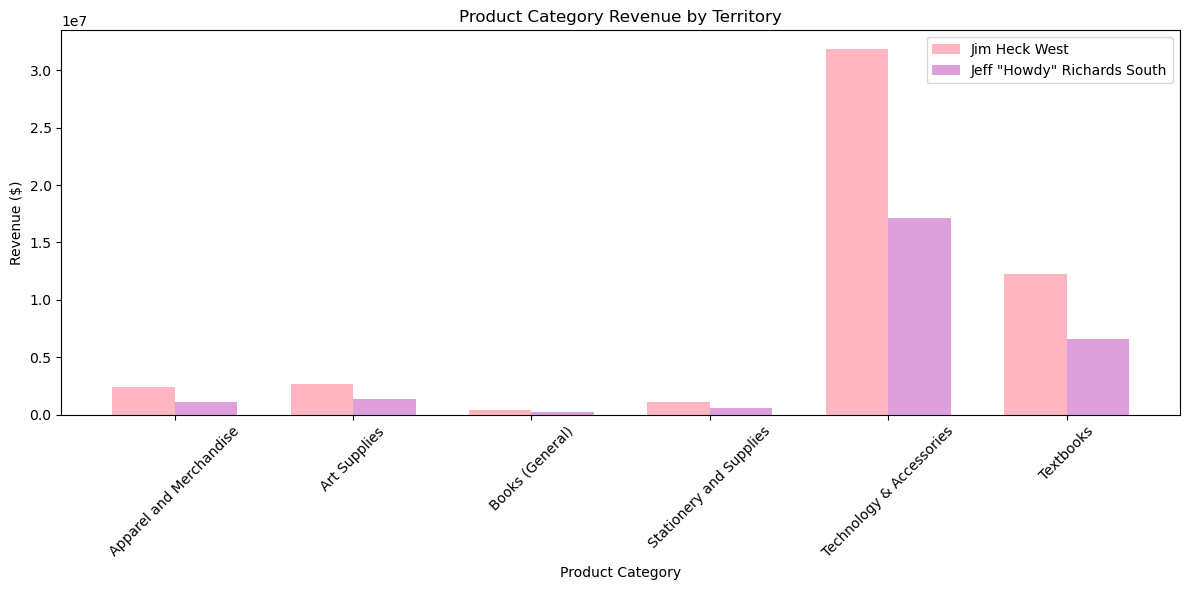

In [402]:
# Create a bar chart for product category revenue by territory

import numpy as np

category_chart = category_sales.pivot(
    index="Category",
    columns="Territory Manager",
    values="Revenue"
).fillna(0)

x = np.arange(len(category_chart.index))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width/2,
    category_chart["Jim Heck"],
    width,
    label="Jim Heck West",
    color="lightpink"
)

plt.bar(
    x + width/2,
    category_chart['Jeff "Howdy" Richards'],
    width,
    label='Jeff "Howdy" Richards South',
    color="plum"
)

plt.title("Product Category Revenue by Territory")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.xticks(x, category_chart.index, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

## Combined:

In [403]:
# Group sales by product category
category_sales = sales_products.groupby(
    ["Category"],
    as_index=False
)["Sale Amount"].sum()

# Rename column
category_sales = category_sales.rename(
    columns={"Sale Amount": "Revenue"}
)

# Sort highest revenue first
category_sales = category_sales.sort_values(
    "Revenue", ascending=False
)

# Show clean table
display(category_sales.style.format({"Revenue": "${:,.2f}"}).hide(axis="index"))

Category,Revenue
Technology & Accessories,"$48,994,687.91"
Textbooks,"$18,807,395.20"
Art Supplies,"$3,969,528.42"
Apparel and Merchandise,"$3,535,701.84"
Stationery and Supplies,"$1,680,853.35"
Books (General),"$663,376.40"


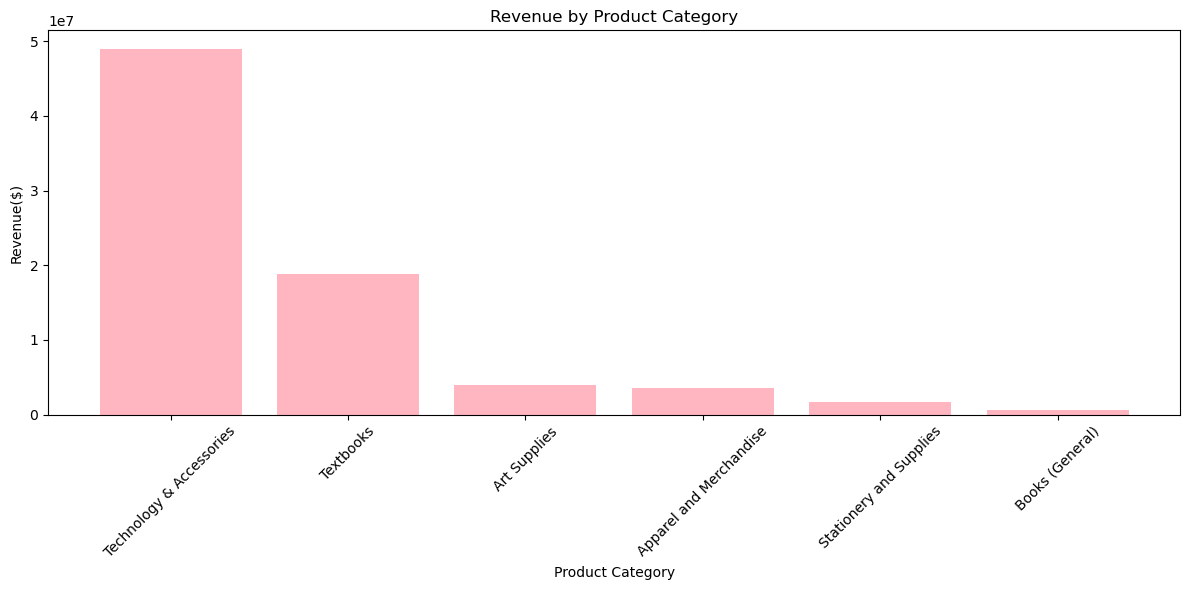

In [404]:
# Bar chart for category revenue
plt.figure(figsize=(12, 6))

plt.bar(
    category_sales["Category"],
    category_sales["Revenue"],
    color="lightpink"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue($)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Question 6: Next Quarter Marketing Recommendation**

After analyzing, I think marketing should be focused on:

1. The highest revenue product categories
2. The highest performing stores
3. Retaining top rewards customers

Because these are the areas already making strong revenue AND offer the best opportunity for more growth.

Also, I think more added promotions could be targeted for lower-performing stores to help them increase sales in those locations/territories.